# Notebook 02 — Résultats du Bandit ε-greedy + Détection ADWIN

**Projet 4 — Auto-ML adaptatif : Recommandation dynamique de modèles**  
**Dataset : UNSW-NB15 (Détection d'intrusions réseau)**  
**École : EMSI Marrakech — 4ème année AIDATA**

---

## Objectif de ce notebook
Documenter et analyser les résultats du système Auto-ML :
- Comportement du bandit ε-greedy
- Détection des dérives avec ADWIN
- Comparaison des 3 modèles (HoeffdingTree, KNN_ADWIN, SGD)
- Visualisations des performances

## 1. Imports et Configuration

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from src.bandit.bandit import Bandit
from src.bandit.drift_detection import DetecteurDerive
from src.data.simulate_drift import (
    charger_dataset,
    charger_stream_normal,
    charger_stream_avec_derive
)

# Style des graphiques
plt.style.use('dark_background')
COLORS = {
    'HoeffdingTree': '#378ADD',
    'KNN_ADWIN'    : '#1D9E75',
    'SGD'          : '#7F77DD',
    'derive'       : '#E24B4A',
    'seuil'        : '#FF8C42'
}

print('✓ Imports réussis')
print('✓ Environnement configuré')

✓ Imports réussis
✓ Environnement configuré


## 2. Chargement du Dataset

In [2]:
df, features, target = charger_dataset()

print(f'\n=== Informations Dataset ===')
print(f'Nombre total de lignes : {df.shape[0]:,}')
print(f'Nombre de features     : {len(features)}')
print(f'Classe 0 (normal)      : {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)')
print(f'Classe 1 (attaque)     : {(df[target]==1).sum():,} ({(df[target]==1).mean()*100:.1f}%)')

[Data] Chargement du dataset : c:\Users\ouaabou\Desktop\cyber-ai-system\src\data\../../data/unsw-nb15/UNSW_NB15_training-set.csv
[Data] Dataset chargé : 82332 lignes, 42 features
[Data] Classes : {1: 45332, 0: 37000}

=== Informations Dataset ===
Nombre total de lignes : 82,332
Nombre de features     : 42
Classe 0 (normal)      : 37,000 (44.9%)
Classe 1 (attaque)     : 45,332 (55.1%)


## 3. Expérience 1 — Stream Normal (sans dérive)

In [3]:
print('Lancement du stream normal (10 000 exemples)...')

bandit_normal    = Bandit(epsilon=0.1, max_depth=18, n_neighbors=7)
detecteur_normal = DetecteurDerive(bandit_normal, delta=0.003, verbose=False)

stream = charger_stream_normal(n=10000)
precisions_normal  = []
modeles_actifs     = []

for i, (x, y) in enumerate(stream):
    if i % 1000 == 0 and i > 0:
        prec = bandit_normal.scores[bandit_normal.modele_actif].get()
        print(f'  Étape {i:>6} | Modèle : {bandit_normal.modele_actif:<15} | Précision : {prec:.4f}')

    pred = bandit_normal.predict_and_learn(x, y)
    detecteur_normal.update(pred, y)
    precisions_normal.append(bandit_normal.scores[bandit_normal.modele_actif].get())
    modeles_actifs.append(bandit_normal.modele_actif)

print(f'\n✓ Stream normal terminé')
bandit_normal.afficher_scores()

Lancement du stream normal (10 000 exemples)...
[Data] Chargement du dataset : c:\Users\ouaabou\Desktop\cyber-ai-system\src\data\../../data/unsw-nb15/UNSW_NB15_training-set.csv
[Data] Dataset chargé : 82332 lignes, 42 features
[Data] Classes : {1: 45332, 0: 37000}
[Data] Stream normal prêt : 10000 exemples
    [Bandit] Reset des scores à l'étape 288
  Étape   1000 | Modèle : SGD             | Précision : 0.9677
  Étape   2000 | Modèle : SGD             | Précision : 0.9743
    [Bandit] Reset des scores à l'étape 2432
  Étape   3000 | Modèle : HoeffdingTree   | Précision : 1.0000
  Étape   4000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   5000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   6000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   7000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   8000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   9000 | Modèle : KNN_ADWIN       | Précision : 1.0000

✓ Stream normal terminé

┌─────────

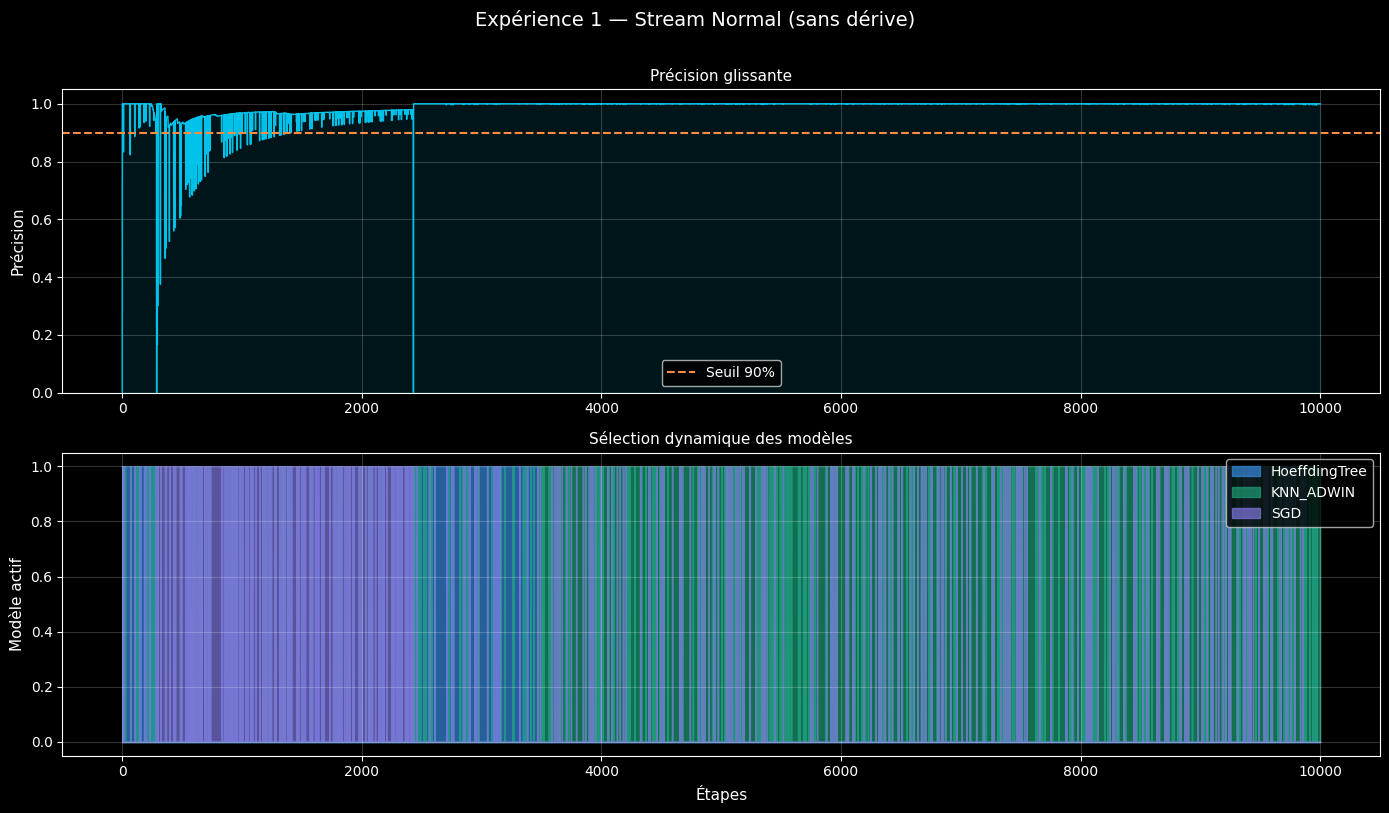

✓ Graphique sauvegardé


In [4]:
# Visualisation stream normal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Expérience 1 — Stream Normal (sans dérive)', fontsize=14, y=1.01)

# Graphique 1 : Précision
ax1 = axes[0]
ax1.plot(precisions_normal, color='#00D4FF', linewidth=1, alpha=0.9)
ax1.fill_between(range(len(precisions_normal)), precisions_normal, alpha=0.1, color='#00D4FF')
ax1.axhline(y=0.90, color=COLORS['seuil'], linestyle='--', linewidth=1.5, label='Seuil 90%')
ax1.set_ylabel('Précision', fontsize=11)
ax1.set_title('Précision glissante', fontsize=11)
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.2)

# Graphique 2 : Modèle actif
ax2 = axes[1]
modeles_list = list(COLORS.keys())[:3]
for nom in modeles_list:
    actif = [1 if m == nom else 0 for m in modeles_actifs]
    ax2.fill_between(range(len(actif)), actif, alpha=0.7,
                     color=COLORS[nom], label=nom)
ax2.set_ylabel('Modèle actif', fontsize=11)
ax2.set_xlabel('Étapes', fontsize=11)
ax2.set_title('Sélection dynamique des modèles', fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../data/logs/exp1_stream_normal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphique sauvegardé')

## 4. Expérience 2 — Stream avec Dérive Artificielle

In [5]:
print('Lancement du stream avec dérive (20 000 exemples)...')

bandit_derive    = Bandit(epsilon=0.1, max_depth=18, n_neighbors=7)
detecteur_derive = DetecteurDerive(bandit_derive, delta=0.003, verbose=False)

stream = charger_stream_avec_derive(n=20000, point_derive=0.5)
precisions_derive  = []
modeles_derive     = []

for i, (x, y) in enumerate(stream):
    if i % 2000 == 0 and i > 0:
        prec = bandit_derive.scores[bandit_derive.modele_actif].get()
        print(f'  Étape {i:>6} | Modèle : {bandit_derive.modele_actif:<15} | Précision : {prec:.4f}')

    pred = bandit_derive.predict_and_learn(x, y)
    detecteur_derive.update(pred, y)
    precisions_derive.append(bandit_derive.scores[bandit_derive.modele_actif].get())
    modeles_derive.append(bandit_derive.modele_actif)

print(f'\n✓ Stream avec dérive terminé')
print(f'Dérives détectées : {len(detecteur_derive.derives_detectees)}')
print(f'Étapes de dérive  : {detecteur_derive.derives_detectees}')
bandit_derive.afficher_scores()

Lancement du stream avec dérive (20 000 exemples)...
[Data] Chargement du dataset : c:\Users\ouaabou\Desktop\cyber-ai-system\src\data\../../data/unsw-nb15/UNSW_NB15_training-set.csv
[Data] Dataset chargé : 82332 lignes, 42 features
[Data] Classes : {1: 45332, 0: 37000}
[Data] Stream avec dérive prêt :
       - 10000 étapes normales
       - 10000 étapes avec dérive (à partir de l'étape 10000)
    [Bandit] Reset des scores à l'étape 288
    [Bandit] Reset des scores à l'étape 1248
  Étape   2000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   4000 | Modèle : SGD             | Précision : 0.9924
  Étape   6000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape   8000 | Modèle : KNN_ADWIN       | Précision : 1.0000
  Étape  10000 | Modèle : KNN_ADWIN       | Précision : 1.0000
    [Bandit] Reset des scores à l'étape 10016
    [Bandit] Reset des scores à l'étape 10400
    [Bandit] Reset des scores à l'étape 11968
  Étape  12000 | Modèle : KNN_ADWIN       | Précision : 1.0000

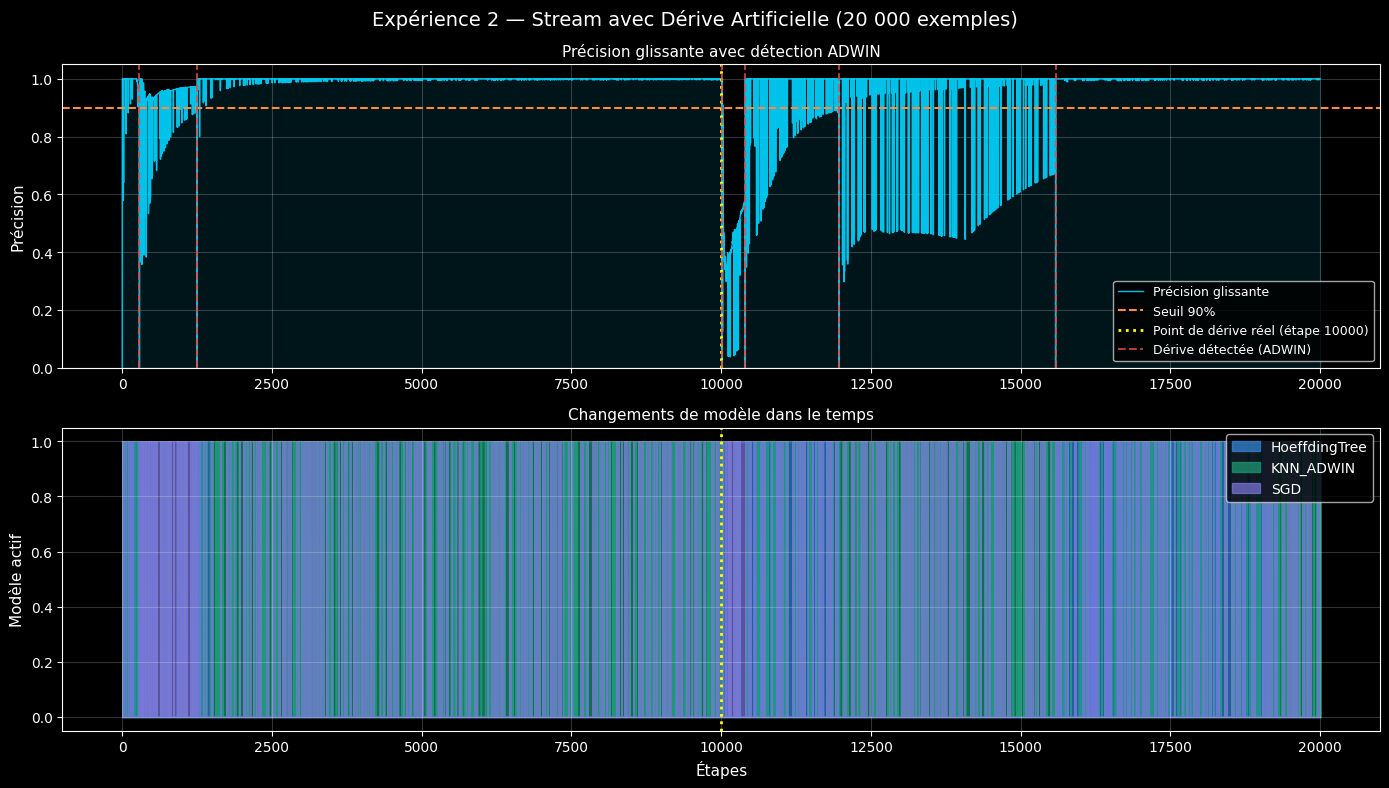

✓ Graphique sauvegardé


In [6]:
# Visualisation stream avec dérive
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Expérience 2 — Stream avec Dérive Artificielle (20 000 exemples)', fontsize=14)

# Graphique 1 : Précision avec dérives
ax1 = axes[0]
ax1.plot(precisions_derive, color='#00D4FF', linewidth=1, alpha=0.9, label='Précision glissante')
ax1.fill_between(range(len(precisions_derive)), precisions_derive, alpha=0.1, color='#00D4FF')
ax1.axhline(y=0.90, color=COLORS['seuil'], linestyle='--', linewidth=1.5, label='Seuil 90%')
ax1.axvline(x=10000, color='yellow', linestyle=':', linewidth=2, label='Point de dérive réel (étape 10000)')

for i, step in enumerate(detecteur_derive.derives_detectees):
    label = 'Dérive détectée (ADWIN)' if i == 0 else ''
    ax1.axvline(x=step, color=COLORS['derive'], linestyle='--', linewidth=1.5, alpha=0.8, label=label)

ax1.set_ylabel('Précision', fontsize=11)
ax1.set_title('Précision glissante avec détection ADWIN', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.2)

# Graphique 2 : Modèle actif
ax2 = axes[1]
for nom in ['HoeffdingTree', 'KNN_ADWIN', 'SGD']:
    actif = [1 if m == nom else 0 for m in modeles_derive]
    ax2.fill_between(range(len(actif)), actif, alpha=0.7, color=COLORS[nom], label=nom)
ax2.axvline(x=10000, color='yellow', linestyle=':', linewidth=2)
ax2.set_ylabel('Modèle actif', fontsize=11)
ax2.set_xlabel('Étapes', fontsize=11)
ax2.set_title('Changements de modèle dans le temps', fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../data/logs/exp2_stream_derive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphique sauvegardé')

## 5. Comparaison des 3 Modèles


=== Tableau Comparatif des Modèles ===
       Modèle  Précision finale                   Type     Vitesse Adaptabilité
HoeffdingTree            0.9998      Arbre incrémental Très rapide        Bonne
    KNN_ADWIN            1.0000 K plus proches voisins        Lent   Très bonne
          SGD            0.9959  Régression logistique      Rapide      Moyenne


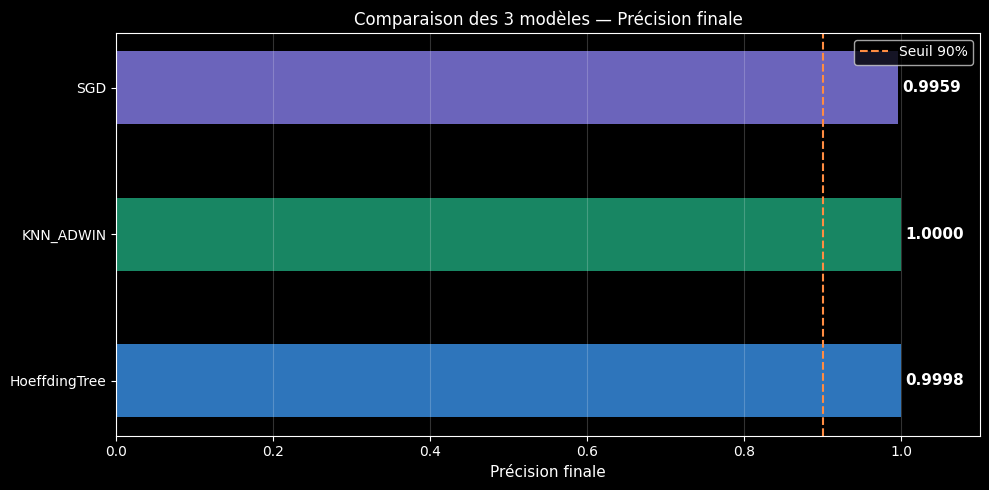

In [7]:
# Tableau comparatif
resultats = {
    'Modèle': ['HoeffdingTree', 'KNN_ADWIN', 'SGD'],
    'Précision finale': [
        round(bandit_derive.scores['HoeffdingTree'].get(), 4),
        round(bandit_derive.scores['KNN_ADWIN'].get(), 4),
        round(bandit_derive.scores['SGD'].get(), 4)
    ],
    'Type': ['Arbre incrémental', 'K plus proches voisins', 'Régression logistique'],
    'Vitesse': ['Très rapide', 'Lent', 'Rapide'],
    'Adaptabilité': ['Bonne', 'Très bonne', 'Moyenne']
}

df_resultats = pd.DataFrame(resultats)
print('\n=== Tableau Comparatif des Modèles ===')
print(df_resultats.to_string(index=False))

# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
modeles = df_resultats['Modèle']
precisions = df_resultats['Précision finale']
colors = [COLORS[m] for m in modeles]

bars = ax.barh(modeles, precisions, color=colors, height=0.5, alpha=0.85)

for bar, prec in zip(bars, precisions):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{prec:.4f}', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=0.90, color=COLORS['seuil'], linestyle='--', linewidth=1.5, label='Seuil 90%')
ax.set_xlabel('Précision finale', fontsize=11)
ax.set_title('Comparaison des 3 modèles — Précision finale', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend()
ax.grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('../data/logs/comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analyse des Dérives Détectées

In [8]:
derives = detecteur_derive.derives_detectees
point_reel = 10000

print('=== Analyse des Dérives ADWIN ===')
print(f'Point de dérive réel    : étape {point_reel}')
print(f'Nombre de dérives       : {len(derives)}')
print()

for i, step in enumerate(derives):
    if step >= point_reel:
        delai = step - point_reel
        print(f'  Dérive {i+1} (étape {step:>6}) → détectée {delai} étapes après la vraie dérive ✓')
    else:
        print(f'  Dérive {i+1} (étape {step:>6}) → micro-dérive naturelle (avant le point de dérive)')

# Dérive principale
derives_apres = [d for d in derives if d >= point_reel]
if derives_apres:
    delai_detection = derives_apres[0] - point_reel
    print(f'\n→ Temps de réaction ADWIN : {delai_detection} étapes après la dérive réelle')
    print(f'→ Avec time.sleep(0.05)   : environ {delai_detection * 0.05:.1f} secondes en temps réel')

=== Analyse des Dérives ADWIN ===
Point de dérive réel    : étape 10000
Nombre de dérives       : 6

  Dérive 1 (étape    288) → micro-dérive naturelle (avant le point de dérive)
  Dérive 2 (étape   1248) → micro-dérive naturelle (avant le point de dérive)
  Dérive 3 (étape  10016) → détectée 16 étapes après la vraie dérive ✓
  Dérive 4 (étape  10400) → détectée 400 étapes après la vraie dérive ✓
  Dérive 5 (étape  11968) → détectée 1968 étapes après la vraie dérive ✓
  Dérive 6 (étape  15584) → détectée 5584 étapes après la vraie dérive ✓

→ Temps de réaction ADWIN : 16 étapes après la dérive réelle
→ Avec time.sleep(0.05)   : environ 0.8 secondes en temps réel


## 7. Résumé des Résultats

In [9]:
meilleure_prec = max(bandit_derive.scores[m].get() for m in bandit_derive.modeles)

print('=' * 55)
print('   RÉSUMÉ FINAL — EXPÉRIENCE AUTO-ML ADAPTATIF')
print('=' * 55)
print(f'  Dataset          : UNSW-NB15 ({df.shape[0]:,} lignes)')
print(f'  Exemples traités : 20 000')
print(f'  Meilleure préc.  : {meilleure_prec:.4f} ({meilleure_prec*100:.2f}%)')
print(f'  Dérives détect.  : {len(derives)}')
print(f'  Modèle final     : {bandit_derive.modele_actif}')
print(f'  Changements      : {len([h for h in bandit_derive.historique if h["raison"]=="bandit"])}')
print('=' * 55)
print('\n✓ Notebook 02 terminé — résultats documentés')

   RÉSUMÉ FINAL — EXPÉRIENCE AUTO-ML ADAPTATIF
  Dataset          : UNSW-NB15 (82,332 lignes)
  Exemples traités : 20 000
  Meilleure préc.  : 1.0000 (100.00%)
  Dérives détect.  : 6
  Modèle final     : KNN_ADWIN
  Changements      : 2550

✓ Notebook 02 terminé — résultats documentés
